# Dataset-size sweep on ts_young (HCP)

Performance of three models — Coupled Hopf (backprop), Neural SDE, and Hybrid Hopf — as the number of training subjects is reduced. Reads per-(size, seed) JSONs from `results/runs/ts_young_{model}_n{N}_seed{S}.json` (written by `train_models.py --max-subjects N --run-suffix n{N}_seed{S}`).

Each panel shows one metric on the y-axis and N (training subjects) on the x-axis, with one line per model. Shaded band = ±1 std across seeds.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

plt.rcParams['figure.dpi'] = 140

In [2]:
# Auto-create parent dirs for savefig (added for reproducible runs)
import matplotlib.figure as _mpl_figure
from pathlib import Path as _Path
_orig_savefig = _mpl_figure.Figure.savefig
def _patched_savefig(self, fname, *args, **kwargs):
    if isinstance(fname, (str, _Path)):
        p = _Path(fname)
        if p.parent and not p.parent.exists():
            p.parent.mkdir(parents=True, exist_ok=True)
    return _orig_savefig(self, fname, *args, **kwargs)
_mpl_figure.Figure.savefig = _patched_savefig


In [ ]:
DATASET = 'ts_young'
SIZES = [10, 94]                    # endpoints actually shown in the figure
# 10 seeds gives the paired Wilcoxon test enough power to surface *, **, *** markers.
# Files generated by REPRODUCE.md §3.
SEEDS = list(range(42, 52))
MODELS = {                            # model_key -> display label, color
    'hopf':         ('Hopf', '#1f77b4'),
    'nsde':         ('Neural SDE',   '#d62728'),
    'hybrid_hopf':  ('Hybrid Hopf',  '#2ca02c'),
}
SPLITS = ['test_inter', 'test_intra']
RESULTS_DIR = project_root / 'results' / 'runs'
OUT_BASE = project_root / 'paper_new'
for sub in ['images/comparison', 'images_png/comparison', 'images_svg/comparison']:
    (OUT_BASE / sub).mkdir(parents=True, exist_ok=True)

# (display_label, metric_key, higher_is_better)
METRICS = [
    ('FC ↑',     'fc_correlation',          True),
    ('FC MSE ↓', 'fc_mse',                  False),
    ('phFC ↑',   'phase_fc_correlation',    True),
    ('FCD ↓',    'fcd_ks',                  False),
    ('phFCD ↓',  'phfcd_ks',                False),
    ('Meta ↓',   'metastability_diff',      False),
    ('TS ↑',     'temporal_correlation',    True),
    ('PSD ↓',    'power_spectrum_distance', False),
    ('Auto ↓',   'autocorr_distance',       False),
]

# Subset averaged for the composite "normalized loss" panel — all lower-is-better,
# distance/MSE-style so they share a direction and behave like reconstruction loss.
LOSS_METRICS = [
    'fc_mse',
    'fcd_mse',
    'phfcd_mse',
    'autocorr_distance',
    'power_spectrum_distance',
]

In [4]:
def load_metric_grid(model_key: str, metric_key: str, split: str = 'test_inter'):
    """Return ndarray (n_sizes, n_seeds) of values, NaN for missing files."""
    out = np.full((len(SIZES), len(SEEDS)), np.nan, dtype=float)
    for ni, n in enumerate(SIZES):
        for si, s in enumerate(SEEDS):
            path = RESULTS_DIR / f'{DATASET}_{model_key}_n{n}_seed{s}.json'
            if not path.exists():
                continue
            payload = json.loads(path.read_text())
            v = payload['metrics'][split].get(metric_key)
            if v is not None:
                out[ni, si] = float(v)
    return out  # (N, S)


def report_missing():
    """Print which (model, size, seed) JSONs are missing."""
    print('Missing JSONs:')
    any_missing = False
    for mkey in MODELS:
        for n in SIZES:
            for s in SEEDS:
                path = RESULTS_DIR / f'{DATASET}_{mkey}_n{n}_seed{s}.json'
                if not path.exists():
                    any_missing = True
                    print(f'  {path.relative_to(project_root)}')
    if not any_missing:
        print('  (none)')

report_missing()

Missing JSONs:
  (none)


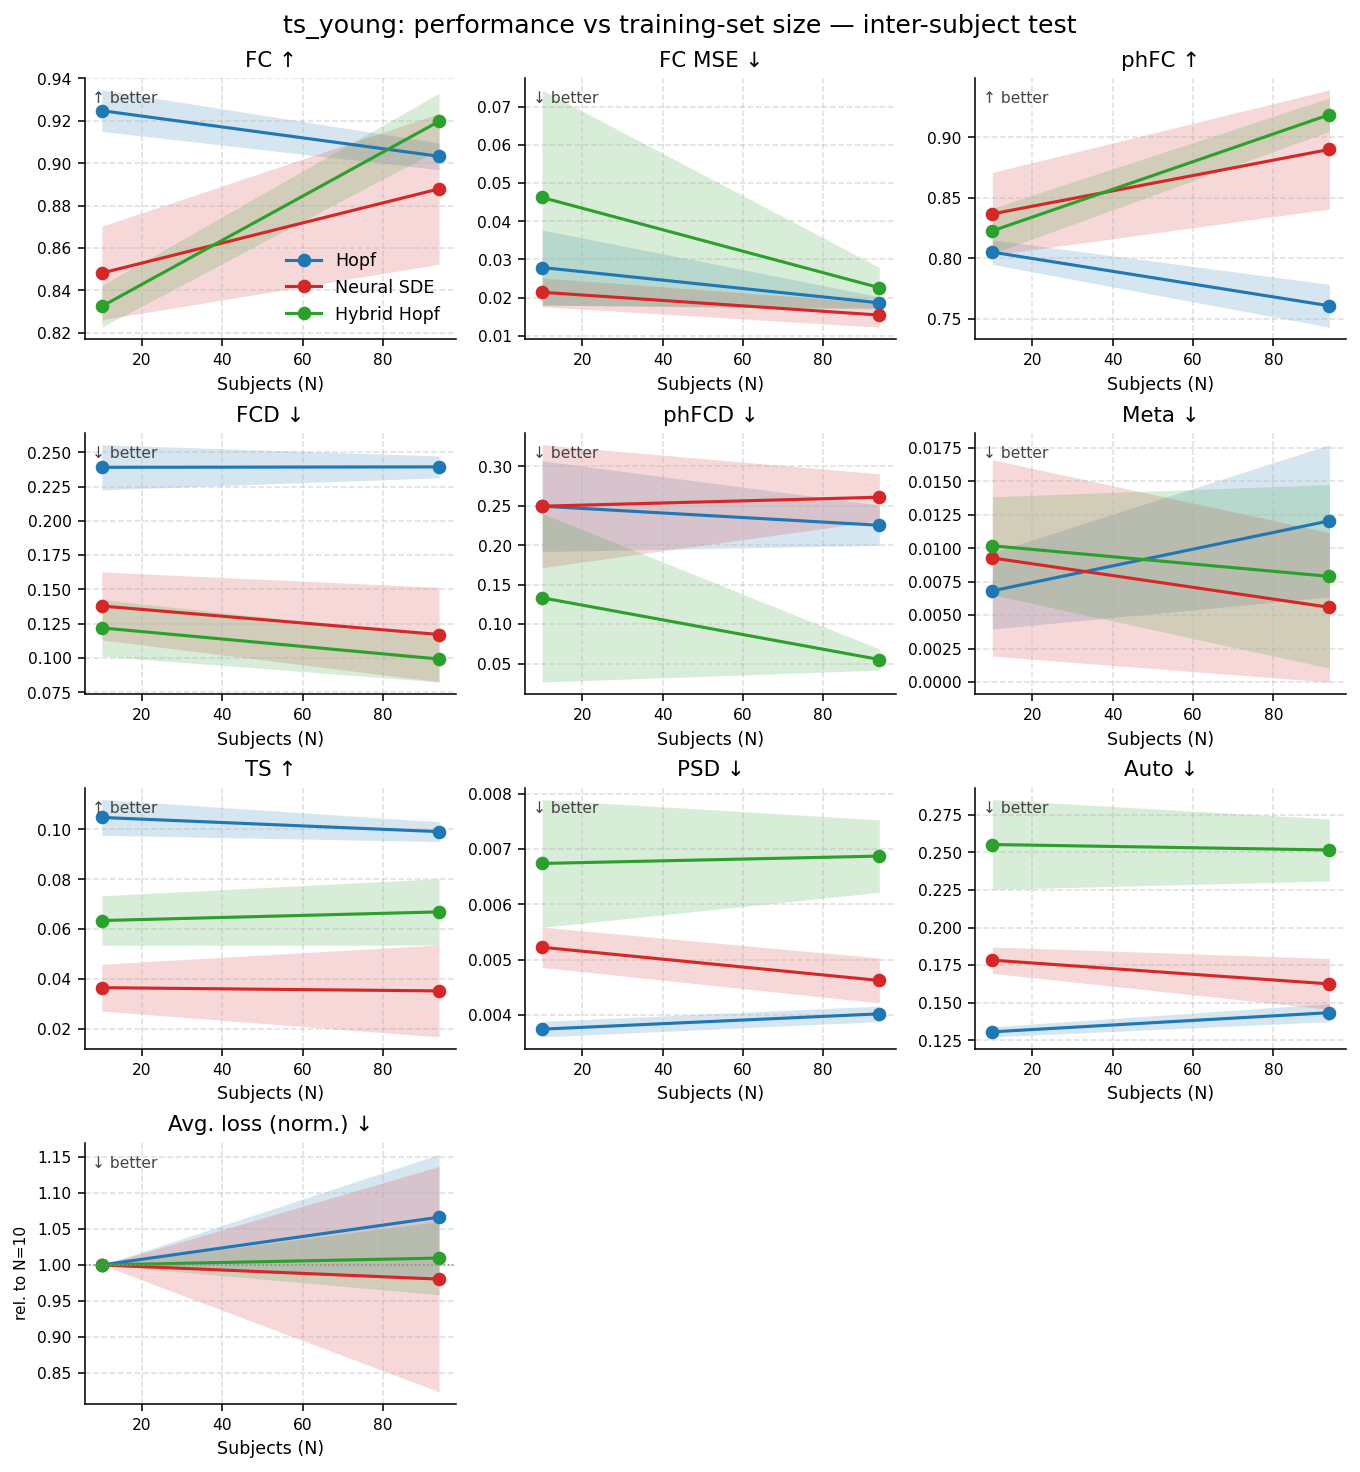

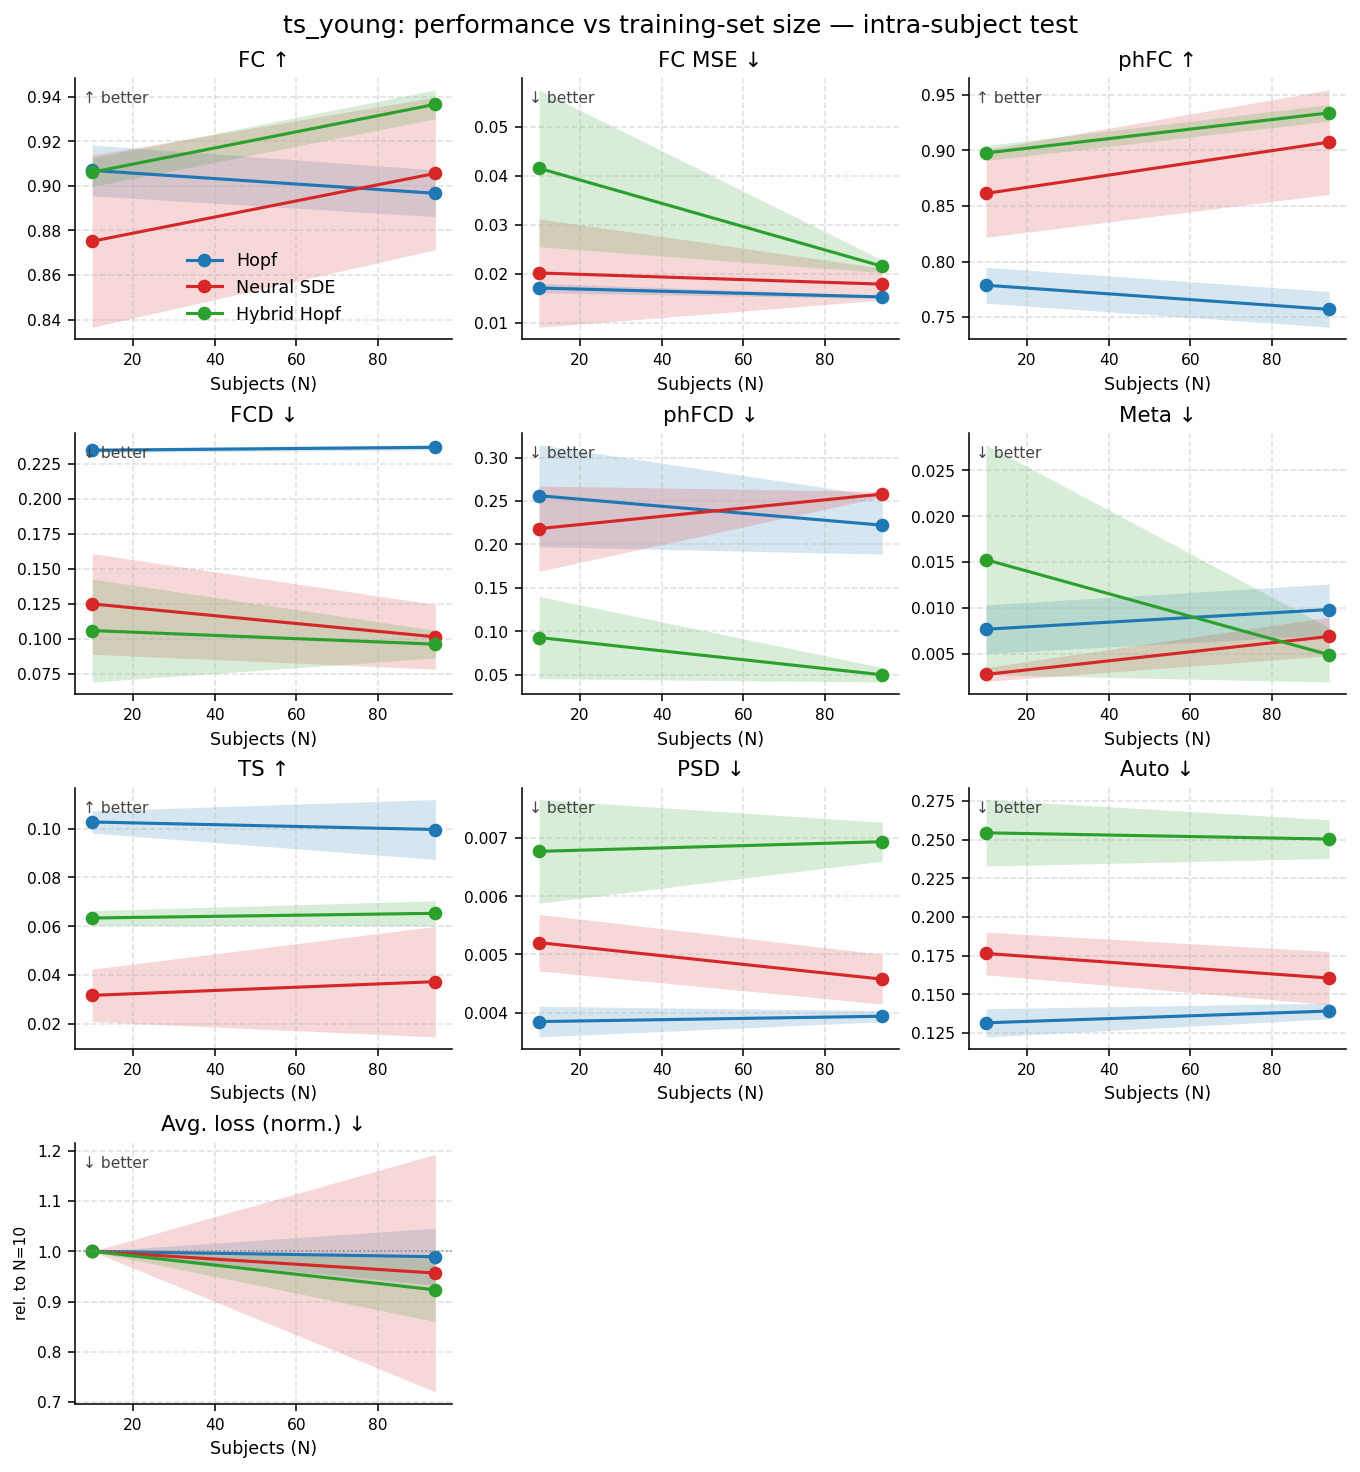

In [5]:
def save(fig, name):
    fig.savefig(OUT_BASE / 'images' / 'comparison' / f'{name}.svg', dpi=200, bbox_inches='tight')
    fig.savefig(OUT_BASE / 'images_png' / 'comparison' / f'{name}.png', dpi=200, bbox_inches='tight')
    fig.savefig(OUT_BASE / 'images_svg' / 'comparison' / f'{name}.svg', bbox_inches='tight')


def composite_loss_grid(model_key: str, split: str):
    """Average of per-metric trajectories normalized by their value at SIZES[0].
    Returns ndarray (n_sizes, n_seeds)."""
    stack = []
    for mkey in LOSS_METRICS:
        g = load_metric_grid(model_key, mkey, split=split)  # (N, S)
        denom = g[0:1, :]                                    # (1, S) — value at smallest N per seed
        with np.errstate(invalid='ignore', divide='ignore'):
            stack.append(g / denom)
    return np.nanmean(np.stack(stack, axis=0), axis=0)       # mean over metrics


def plot_split(split: str):
    panels = METRICS + [('Avg. loss (norm.) ↓', '__composite__', False)]
    n_panels = len(panels)
    n_cols = 3
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.6 * n_rows), constrained_layout=True)
    fig.patch.set_alpha(0.0)
    axes = np.atleast_2d(axes)

    for idx, (label, mkey, higher_better) in enumerate(panels):
        ax = axes.flat[idx]
        for model_key, (model_label, color) in MODELS.items():
            if mkey == '__composite__':
                grid = composite_loss_grid(model_key, split)
            else:
                grid = load_metric_grid(model_key, mkey, split=split)
            mean = np.nanmean(grid, axis=1)
            std = np.nanstd(grid, axis=1, ddof=1) if grid.shape[1] > 1 else np.zeros_like(mean)
            ax.plot(SIZES, mean, marker='o', color=color, label=model_label, linewidth=1.6)
            ax.fill_between(SIZES, mean - std, mean + std, color=color, alpha=0.18, linewidth=0)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('Subjects (N)', fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)
        arrow = '↑ better' if higher_better else '↓ better'
        ax.text(0.02, 0.95, arrow, transform=ax.transAxes, fontsize=8, va='top', color='#444444')
        if mkey == '__composite__':
            ax.axhline(1.0, color='#888', linewidth=0.8, linestyle=':')
            ax.set_ylabel('rel. to N=%d' % SIZES[0], fontsize=8)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)

    for idx in range(n_panels, n_rows * n_cols):
        axes.flat[idx].axis('off')

    axes.flat[0].legend(loc='best', fontsize=9, frameon=False)
    pretty = {'test_inter': 'inter-subject test', 'test_intra': 'intra-subject test'}[split]
    fig.suptitle(f'{DATASET}: performance vs training-set size — {pretty}', fontsize=13)
    save(fig, f'{DATASET}_dataset_size_sweep_{split}')
    plt.show()


for split in SPLITS:
    plot_split(split)

In [6]:
# Ranked relative improvement from N=SIZES[0] to N=SIZES[-1].
# For lower-is-better: (small - large) / |small|. For higher-is-better: (large - small) / |small|.
# Positive = data helped. Sorted descending so the metric that "maximizes the more-data effect" sits on top.

def rel_improvement(grid: np.ndarray, higher_better: bool) -> float:
    small = np.nanmean(grid[0])
    large = np.nanmean(grid[-1])
    if not np.isfinite(small) or not np.isfinite(large) or small == 0:
        return np.nan
    return (large - small) / abs(small) if higher_better else (small - large) / abs(small)


rows = []
for split in SPLITS:
    for label, mkey, higher_better in METRICS:
        per_model = {}
        for model_key in MODELS:
            g = load_metric_grid(model_key, mkey, split=split)
            per_model[model_key] = rel_improvement(g, higher_better)
        avg = np.nanmean(list(per_model.values()))
        rows.append((split, label, mkey, avg, per_model))

rows.sort(key=lambda r: (-r[3] if np.isfinite(r[3]) else 1.0))

print(f'Relative improvement N={SIZES[0]} → N={SIZES[-1]} (positive = more data helped)')
print(f'{"split":<11}{"metric":<10}{"avg":>8}   ' + '  '.join(f'{m:>10}' for m in MODELS))
print('-' * 72)
for split, label, _mkey, avg, per_model in rows:
    cells = '  '.join(f'{per_model[m]:>+10.3f}' if np.isfinite(per_model[m]) else f'{"nan":>10}' for m in MODELS)
    avg_s = f'{avg:>+8.3f}' if np.isfinite(avg) else f'{"nan":>8}'
    print(f'{split:<11}{label:<10}{avg_s}   {cells}')

# Composite (avg-loss) improvement per (split, model):
print()
print('Composite avg-loss improvement (1 - value@N_max, since trajectories start at 1.0):')
for split in SPLITS:
    parts = []
    for model_key, (label, _) in MODELS.items():
        g = composite_loss_grid(model_key, split)
        large = np.nanmean(g[-1])
        parts.append(f'{label}: {1.0 - large:+.3f}')
    print(f'  {split}: ' + '  |  '.join(parts))

Relative improvement N=10 → N=94 (positive = more data helped)
split      metric         avg         hopf        nsde  hybrid_hopf
------------------------------------------------------------------------
test_inter FC MSE ↓    +0.374       +0.332      +0.279      +0.511
test_intra FC MSE ↓    +0.234       +0.107      +0.113      +0.482
test_inter phFCD ↓     +0.213       +0.097      -0.045      +0.586
test_intra phFCD ↓     +0.138       +0.133      -0.183      +0.463
test_inter FCD ↓       +0.112       -0.001      +0.151      +0.186
test_intra FCD ↓       +0.090       -0.009      +0.188      +0.092
test_intra TS ↑        +0.059       -0.030      +0.178      +0.030
test_inter FC ↑        +0.043       -0.023      +0.047      +0.105
test_inter phFC ↑      +0.042       -0.055      +0.064      +0.117
test_intra PSD ↓       +0.024       -0.024      +0.121      -0.024
test_intra phFC ↑      +0.022       -0.028      +0.054      +0.040
test_intra FC ↑        +0.019       -0.011      +0.035     

In [ ]:
# Composite "average score" panel: N=10 vs N=94 on test_intra, grouped bars per model.
# Uses the standard FC-modeling benchmark suite: static FC + phase FC, plus dynamic
# FCD + phase FCD (KS distances). ↑-is-better metrics are flipped to (1 - value) so
# all directions match (lower = better). Per seed we take the unweighted mean across
# the 4 metrics, then mean ± std across seeds.
#
# Significance markers come from a paired Wilcoxon test across seeds
# (N=10 vs N=94, per model): * p<0.05, ** p<0.01, *** p<0.001.

from scipy.stats import wilcoxon


def _sig_marker(p):
    if p is None or np.isnan(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def paired_wilcoxon(a, b):
    """Two-sided paired Wilcoxon p-value. Returns NaN when undefined."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    a, b = a[mask], b[mask]
    if a.size < 2 or np.allclose(a, b):
        return float('nan')
    try:
        _, p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
    except ValueError:
        return float('nan')
    return float(p)


SPLIT = 'test_intra'
SHOW_SIZES = [10, 94]
size_idx = [SIZES.index(n) for n in SHOW_SIZES]

OLD_COLOR = '#C0C0C0'   # N=10
NEW_COLOR = '#104870'   # N=94

# Standard FC-modeling benchmarks: static FC (corr + phase) and dynamic FC (KS in
# magnitude + phase). Excludes spectral/temporal metrics (PSD, Auto, TS, FC MSE,
# Meta) which probe properties orthogonal to FC structure.
COMPOSITE_INCLUDE = ['fc_correlation', 'phase_fc_correlation', 'fcd_ks', 'phfcd_ks']


def composite_score_grid(model_key: str, split: str):
    """Per-seed mean across COMPOSITE_INCLUDE, with ↑-is-better metrics flipped to
    (1 - v). Returns ndarray (n_sizes, n_seeds), lower = better."""
    higher_better_map = {k: hb for _l, k, hb in METRICS}
    stack = []
    for k in COMPOSITE_INCLUDE:
        g = load_metric_grid(model_key, k, split=split)
        stack.append(1.0 - g if higher_better_map[k] else g)
    return np.nanmean(np.stack(stack, axis=0), axis=0)


model_keys = list(MODELS.keys())
labels = [MODELS[m][0] for m in model_keys]
x = np.arange(len(model_keys))
width = 0.36

low_mean, low_std, high_mean, high_std = [], [], [], []
pvals = {}
for m in model_keys:
    grid = composite_score_grid(m, SPLIT)[size_idx]                 # (2, S)
    means = np.nanmean(grid, axis=1)
    stds = np.nanstd(grid, axis=1, ddof=1) if grid.shape[1] > 1 else np.zeros_like(means)
    low_mean.append(means[0]);  low_std.append(stds[0])
    high_mean.append(means[1]); high_std.append(stds[1])
    pvals[m] = paired_wilcoxon(grid[0], grid[1])

print(f'Composite score (mean across {COMPOSITE_INCLUDE}, ↑ flipped to 1-v), {SPLIT}')
print(f'Paired Wilcoxon across {len(SEEDS)} seeds (* p<0.05, ** p<0.01, *** p<0.001)')
print(f'{"model":<14}{"N=10 mean":>12}{"N=10 std":>12}{"N=94 mean":>12}{"N=94 std":>12}{"Δ (improv.)":>14}{"p":>10}{"sig":>5}')
for mkey, lbl, lm, ls, hm, hs in zip(model_keys, labels, low_mean, low_std, high_mean, high_std):
    p = pvals[mkey]
    p_s = f'{p:>10.4f}' if not np.isnan(p) else f'{"nan":>10}'
    print(f'{lbl:<14}{lm:>12.5f}{ls:>12.5f}{hm:>12.5f}{hs:>12.5f}{lm - hm:>+14.5f}{p_s}{_sig_marker(p):>5}')

fig_w = max(4.0, 0.9 * len(model_keys) + 1.5)
fig, ax = plt.subplots(figsize=(3.5, 2.2)) #(fig_w, 2.0))
fig.patch.set_alpha(0.0)

ax.bar(x - width / 2, low_mean,  width, yerr=low_std,  color=OLD_COLOR,
       edgecolor='none', capsize=3, label=f'N={SHOW_SIZES[0]}',
       error_kw=dict(ecolor='black', lw=1.0))
ax.bar(x + width / 2, high_mean, width, yerr=high_std, color=NEW_COLOR,
       edgecolor='none', capsize=3, label=f'N={SHOW_SIZES[-1]}',
       error_kw=dict(ecolor='black', lw=1.0))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
#ax.set_title('HCP: dataset-size effect', fontsize=12)
y_top = max(max(lm + ls for lm, ls in zip(low_mean, low_std)),
            max(hm + hs for hm, hs in zip(high_mean, high_std)))
ax.set_ylim(0, y_top * 1.25)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10, ncols=1, title='Training set size')

# Significance markers above each pair of bars.
for i, mkey in enumerate(model_keys):
    marker = _sig_marker(pvals[mkey])
    if not marker:
        continue
    top = max(low_mean[i] + low_std[i], high_mean[i] + high_std[i])
    ax.text(x[i], top, marker, ha='center', va='bottom', fontsize=10)

plt.tight_layout()

save(fig, f'{DATASET}_dataset_size_sweep_composite_{SPLIT}_endpoints')
plt.show()

=== test_intra: per-metric mean ± std across 3 seeds ===

-- FC ↑ (fc_correlation) --
model                         N=10                N=94
Hopf              0.9070 ± 0.0114    0.8967 ± 0.0105
Neural SDE        0.8752 ± 0.0386    0.9056 ± 0.0342
Hybrid Hopf       0.9062 ± 0.0064    0.9366 ± 0.0065

-- FC MSE ↓ (fc_mse) --
model                         N=10                N=94
Hopf              0.0171 ± 0.0010    0.0153 ± 0.0003
Neural SDE        0.0202 ± 0.0111    0.0179 ± 0.0033
Hybrid Hopf       0.0415 ± 0.0160    0.0215 ± 0.0013

-- phFC ↑ (phase_fc_correlation) --
model                         N=10                N=94
Hopf              0.7787 ± 0.0162    0.7570 ± 0.0161
Neural SDE        0.8613 ± 0.0395    0.9075 ± 0.0470
Hybrid Hopf       0.8977 ± 0.0067    0.9339 ± 0.0074

-- FCD ↓ (fcd_ks) --
model                         N=10                N=94
Hopf              0.2347 ± 0.0016    0.2368 ± 0.0019
Neural SDE        0.1250 ± 0.0359    0.1016 ± 0.0231
Hybrid Hopf       0.1061 ± 

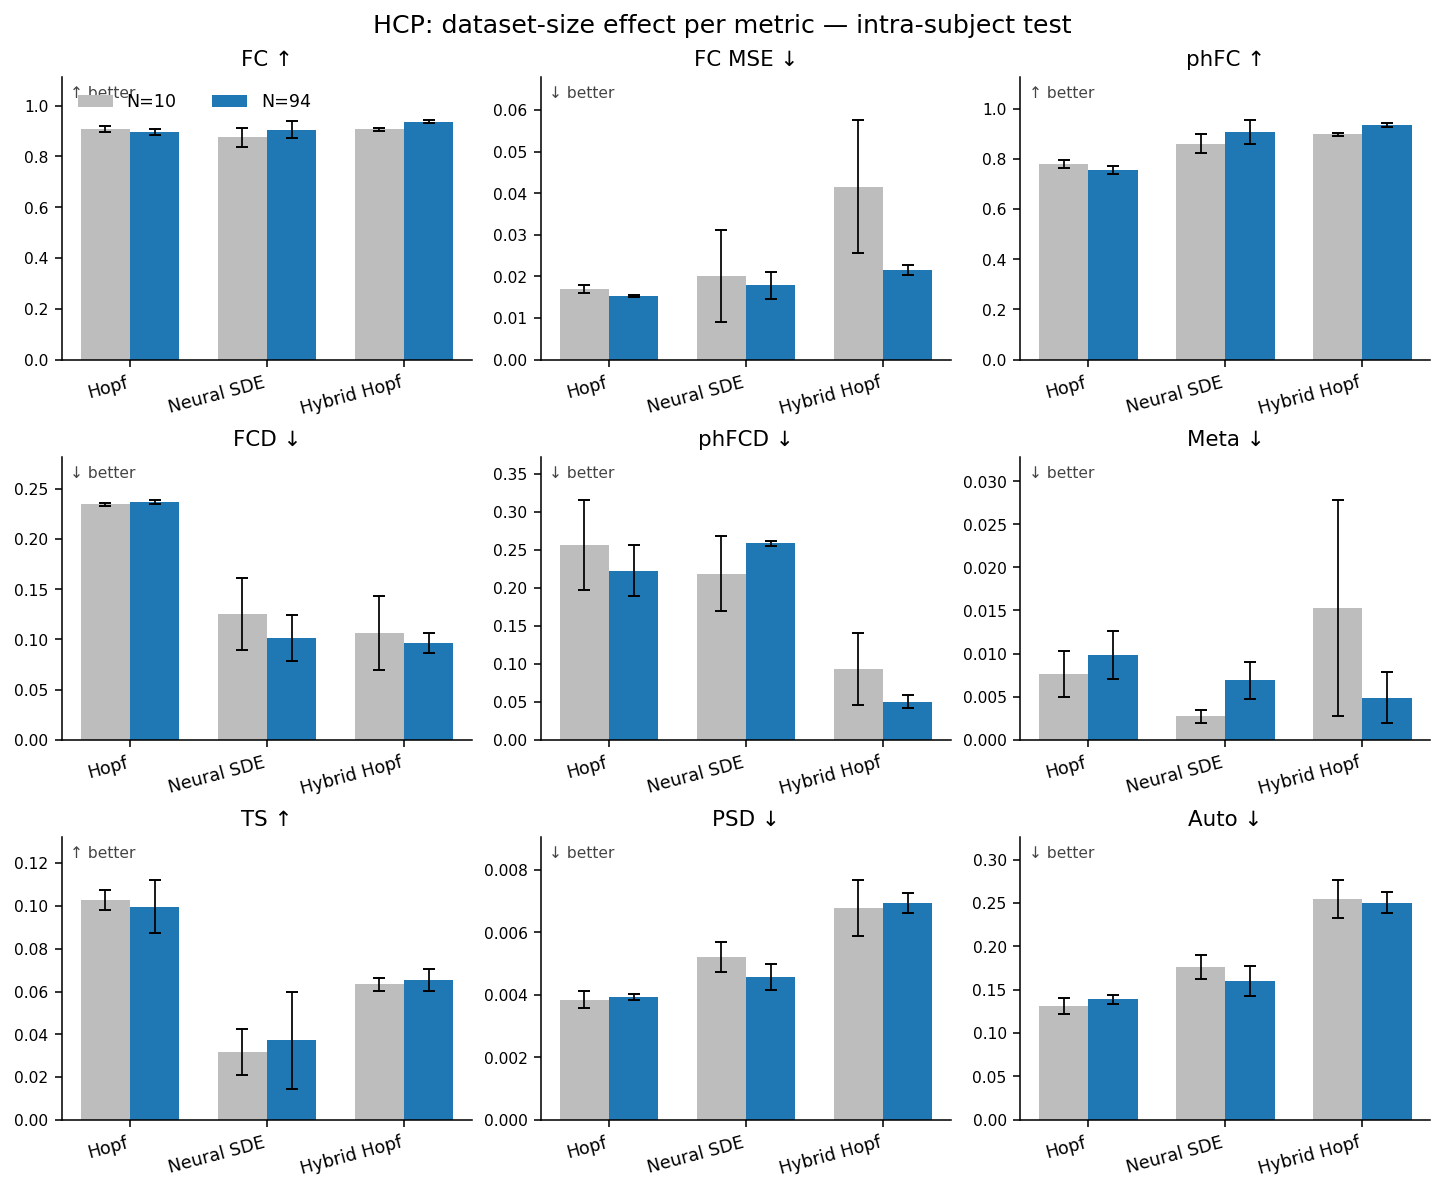

In [8]:
# Per-metric grouped bars: N=10 vs N=94 for each model, one panel per metric in METRICS.
# Bars show mean ± std across seeds. Arrow on each panel indicates direction (↑/↓).

SPLIT = 'test_intra'
SHOW_SIZES = [10, 94]
size_idx = [SIZES.index(n) for n in SHOW_SIZES]

OLD_COLOR = '#bdbdbd'   # N=10
NEW_COLOR = '#1f77b4'   # N=94

model_keys = list(MODELS.keys())
labels = [MODELS[m][0] for m in model_keys]
x = np.arange(len(model_keys))
width = 0.36

n_panels = len(METRICS)
n_cols = 3
n_rows = (n_panels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 2.8 * n_rows), constrained_layout=True)
fig.patch.set_alpha(0.0)
axes = np.atleast_2d(axes)

print(f'=== {SPLIT}: per-metric mean ± std across {len(SEEDS)} seeds ===')

for idx, (label, mkey, higher_better) in enumerate(METRICS):
    ax = axes.flat[idx]
    low_mean, low_std, high_mean, high_std = [], [], [], []
    for m in model_keys:
        grid = load_metric_grid(m, mkey, split=SPLIT)[size_idx]      # (2, S)
        means = np.nanmean(grid, axis=1)
        stds = np.nanstd(grid, axis=1, ddof=1) if grid.shape[1] > 1 else np.zeros_like(means)
        low_mean.append(means[0]);  low_std.append(stds[0])
        high_mean.append(means[1]); high_std.append(stds[1])

    print(f'\n-- {label} ({mkey}) --')
    print(f'{"model":<14}{"N=10":>20}{"N=94":>20}')
    for lbl, lm, ls, hm, hs in zip(labels, low_mean, low_std, high_mean, high_std):
        print(f'{lbl:<14}{lm:>10.4f} ± {ls:<6.4f}{hm:>10.4f} ± {hs:<6.4f}')

    ax.bar(x - width / 2, low_mean,  width, yerr=low_std,  color=OLD_COLOR,
           edgecolor='none', capsize=3, label=f'N={SHOW_SIZES[0]}',
           error_kw=dict(ecolor='black', lw=0.9))
    ax.bar(x + width / 2, high_mean, width, yerr=high_std, color=NEW_COLOR,
           edgecolor='none', capsize=3, label=f'N={SHOW_SIZES[-1]}',
           error_kw=dict(ecolor='black', lw=0.9))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_axisbelow(True)
    arrow = '↑ better' if higher_better else '↓ better'
    ax.text(0.02, 0.97, arrow, transform=ax.transAxes, fontsize=8, va='top', color='#444')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

    y_top = max(max(lm + ls for lm, ls in zip(low_mean, low_std)),
                max(hm + hs for hm, hs in zip(high_mean, high_std)))
    y_bot = min(0.0, min(lm - ls for lm, ls in zip(low_mean, low_std)),
                min(hm - hs for hm, hs in zip(high_mean, high_std)))
    ax.set_ylim(y_bot, y_top * 1.18 if y_top > 0 else 1.0)

for idx in range(n_panels, n_rows * n_cols):
    axes.flat[idx].axis('off')

axes.flat[0].legend(loc='upper left', fontsize=9, frameon=False, ncols=2)
pretty = {'test_inter': 'inter-subject test', 'test_intra': 'intra-subject test'}[SPLIT]
fig.suptitle(f'HCP: dataset-size effect per metric — {pretty}', fontsize=13)

save(fig, f'{DATASET}_dataset_size_sweep_per_metric_{SPLIT}_endpoints')
plt.show()

## How to regenerate the underlying JSON

See **§3 of [REPRODUCE.md](../REPRODUCE.md)** for the canonical commands (10 seeds × 2 sizes × 3 models = 60 jobs). The minimal loop is:

```bash
DATA_ARGS="--dataset-type ts_young --data-path data/ts_young/ts_young_TR0.72.mat"
for s in 42 43 44 45 46 47 48 49 50 51; do
  for n in 10 94; do
    for m in hopf nsde hybrid_hopf; do
      sbatch -M tinygpu --gres=gpu:1 --time=02:00:00 \
        --wrap=".venv/bin/python examples/train_models.py backprop --model $m $DATA_ARGS --no-wandb --max-subjects $n --seed $s --run-suffix n${n}_seed${s}"
    done
  done
done
```

To start with a single seed (6 jobs) and add more later, run only `s=42`. Paired Wilcoxon needs ≥ 5 paired samples to produce useful p-values, so plan on running at least 10 seeds before adding significance markers to the paper.